# 04 - Future Demand Forecasting

Use the trained LSTM recursively to forecast multiple future days.

The same predicted value becomes part of the next input window.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

train = pd.read_csv("../data/train.csv", parse_dates=["date"])

STORE_ID = 1
ITEM_ID = 1
LOOKBACK = 30
HORIZON = 30

series = (
    train[(train["store"] == STORE_ID) & (train["item"] == ITEM_ID)]
    .sort_values("date")
    [["date", "sales"]]
    .reset_index(drop=True)
)

values = series["sales"].values.astype("float32").reshape(-1, 1)

# For a standalone forecasting demonstration, fit the scaler on all
# available historical data and load the model if it exists.
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

model = tf.keras.models.load_model("../models/demand_lstm.keras")

In [2]:
window = scaled_values[-LOOKBACK:].copy()
future_scaled = []

for _ in range(HORIZON):
    x = window.reshape(1, LOOKBACK, 1)
    next_value = model.predict(x, verbose=0)[0, 0]
    future_scaled.append(next_value)

    window = np.vstack([
        window[1:],
        [[next_value]]
    ])

future_sales = scaler.inverse_transform(
    np.array(future_scaled).reshape(-1, 1)
).flatten()

future_sales = np.maximum(future_sales, 0)

future_dates = pd.date_range(
    series["date"].iloc[-1] + pd.Timedelta(days=1),
    periods=HORIZON,
    freq="D"
)

forecast = pd.DataFrame({
    "date": future_dates,
    "forecast_sales": future_sales
})

forecast.head()

C:\Users\user\AppData\Local\Temp\ipykernel_6592\4060264885.py:21: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  series["date"].iloc[-1] + pd.Timedelta(days=1),


,date,forecast_sales
0,2018-01-01,16.717258
1,2018-01-02,17.030916
2,2018-01-03,17.253302
3,2018-01-04,17.468122
4,2018-01-05,17.616877


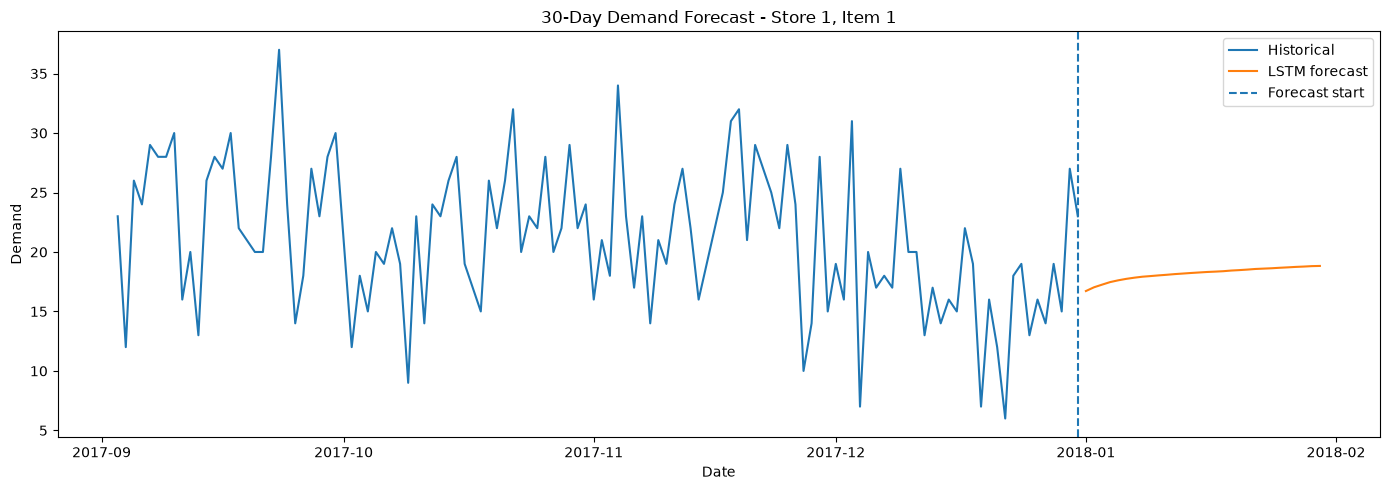

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(series["date"].tail(120), series["sales"].tail(120), label="Historical")
plt.plot(forecast["date"], forecast["forecast_sales"], label="LSTM forecast")
plt.axvline(series["date"].iloc[-1], linestyle="--", label="Forecast start")
plt.title(f"30-Day Demand Forecast - Store {STORE_ID}, Item {ITEM_ID}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

## Important limitation

Recursive forecasting can accumulate error because each future prediction is fed back into the model.

In a production system, you could investigate direct multi-horizon models, probabilistic forecasts, richer covariates, hierarchical forecasting, model monitoring and retraining.